In [13]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [1]:
%cd home/ubuntu/foundation_model_multiplexed_imaging/models/virtue/


[Errno 2] No such file or directory: 'home/ubuntu/foundation_model_multiplexed_imaging/models/virtue/'
/vol/data/foundation_model_multiplexed_imaging/models/virtue/notebooks


In [2]:
#Extract Embddings from .pt file 

import torch
import os

# Pfade anpassen auf marker_embeddings
base_path = "/vol/data/foundation_model_multiplexed_imaging/models/virtue"
input_dir = os.path.join(base_path, "assets/old_marker_embeddings")
output_dir = os.path.join(base_path, "assets/cleaned_embeddings")

os.makedirs(output_dir, exist_ok=True)

print(f"Lade Dateien aus: {input_dir}")
files = [f for f in os.listdir(input_dir) if f.endswith(".pt")]
print(f"Gefundene .pt Dateien: {len(files)}\n")

for file in sorted(files):
    path = os.path.join(input_dir, file)
    data = torch.load(path, map_location='cpu')
    
    # Extraktion aus der ESM-Struktur
    if isinstance(data, dict) and 'mean_representations' in data:
        # Den Layer-Index automatisch bestimmen (z.B. 33)
        layer = list(data['mean_representations'].keys())[0]
        tensor = data['mean_representations'][layer]
        
        # Speichern des reinen Tensors
        torch.save(tensor, os.path.join(output_dir, file))
        
        # Details printen
        print(f"✅ {file}")
        print(f"   Shape: {list(tensor.shape)}")
        print(f"   Mean:  {tensor.mean().item():.4f}")
    else:
        print(f"⚠️  {file} übersprungen (keine 'mean_representations' gefunden)")

print(f"\nFertig! Die bereinigten Tensoren liegen in: {output_dir}")

Lade Dateien aus: /vol/data/foundation_model_multiplexed_imaging/models/virtue/assets/old_marker_embeddings
Gefundene .pt Dateien: 3

✅ P60709.pt
   Shape: [640]
   Mean:  0.0036
✅ P68431.pt
   Shape: [640]
   Mean:  0.0035
✅ P68871.pt
   Shape: [640]
   Mean:  0.0034

Fertig! Die bereinigten Tensoren liegen in: /vol/data/foundation_model_multiplexed_imaging/models/virtue/assets/cleaned_embeddings


In [4]:
%cd ..

/vol/data/foundation_model_multiplexed_imaging/models/virtue


In [5]:
import os
from omegaconf import OmegaConf
import torch
from modules.multiplex_virtues import MultiplexVirtues
from utils.utils import load_marker_embeddings, load_marker_embedding_dict
from safetensors.torch import load_file

# path definition 
PATH_BASE_CONFIG = "configs/base_config.yaml"
PATH_MARKER_EMBEDDINGS = "assets/cleaned_embeddings/"
weights_dir = "assets/checkpoints" 
weights_filename = "model.safetensors"
weights_full_path = os.path.join(weights_dir, weights_filename)

# gather variables needed for model 
config = OmegaConf.load(PATH_BASE_CONFIG)
print("Config is loaded succesfully, yuhu")

bias_embeddings = load_marker_embeddings(PATH_MARKER_EMBEDDINGS)
bias_embeddings_dict = load_marker_embedding_dict(PATH_MARKER_EMBEDDINGS) # Klammern ergänzt
print("\n--- 🔍 Sanity Check: Embeddings ---")
print(f"Gesamt-Tensor Shape: {bias_embeddings.shape}")

model = MultiplexVirtues(
    use_default_config=False,
    prior_bias_embeddings=bias_embeddings, # Loaded from your cleaned_embeddings
    prior_bias_embedding_type='esm', # Since you are using ESM embeddings
    patch_size=config.model.patch_size, # Accessing OmegaConf attributes with dot notation
    model_dim=config.model.model_dim,
    feedforward_dim=config.model.feedforward_dim,
    encoder_pattern=config.model.encoder_pattern,
    num_encoder_heads=config.model.num_encoder_heads,
    decoder_pattern=config.model.decoder_pattern,
    num_decoder_heads=config.model.num_decoder_heads,
    num_hidden_layers=config.model.num_decoder_hidden_layers,
    positional_embedding_type=config.model.positional_embedding_type,
    dropout=0.0, # Best practice for inference to ensure deterministic output
    group_layers=config.model.group_layers,
    norm_after_encoder_decoder=config.model.norm_after_encoder_decoder,
    verbose=True
)

# --- 2. Loading the Weights ---
print(f"Loading weights from: {weights_full_path}")

# Load the weights from the safetensors file
state_dict = load_file(weights_full_path)

# Load the state_dict into the model
# strict=False is often safer if there are minor naming differences in keys
model.load_state_dict(state_dict, strict=False)

# --- 3. Final Preparation ---
# Set the model to evaluation mode (disables dropout)
model.eval()

# Move the model to GPU if available for faster inference
if torch.cuda.is_available():
    model.cuda()
    print("✅ Model instantiated and moved to GPU.")
else:
    print("✅ Model instantiated on CPU.")

Config is loaded succesfully, yuhu

--- 🔍 Sanity Check: Embeddings ---
Gesamt-Tensor Shape: torch.Size([3, 640])
Using addition for prior_embedding fusion
Loading weights from: assets/checkpoints/model.safetensors
✅ Model instantiated and moved to GPU.


In [11]:
import gc
import torch

# Lösche alte Variablen, falls sie noch existieren
if 'output' in locals(): del output
if 'images_list' in locals(): del images_list

# Erzwinge die Müllabfuhr
gc.collect()
# Leere den PyTorch Cache
torch.cuda.empty_cache()

print(f"Freier Speicher auf GPU: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

Freier Speicher auf GPU: 12.51 GB


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset  # Subset hinzugefügt
import numpy as np
import pandas as pd
from einops import rearrange
from tqdm import tqdm
from typing import Any

# --- SETTINGS & PATHS ---
DATA_PATH = "datasets/bloodmnist_128/bloodmnist_128.npz"
USE_SUBSET = True  # SCHALTER: True = nur 24 Bilder, False = alle Bilder

# --- GLOBAL STATISTICS CALCULATION ---
# We calculate statistics on the fly from the raw data to ensure correct normalization
data = np.load(DATA_PATH)
# Images are usually (N, 128, 128, 3), scaled to [0, 1]
images_raw = data['train_images'].astype("float32") / 255.0
images_tensor = torch.from_numpy(images_raw)

# Calculate global mean and std per channel [R, G, B]
global_mean = images_tensor.mean(dim=(0, 1, 2))
global_std = images_tensor.std(dim=(0, 1, 2))

print(f"Global Mean (RGB): {global_mean}")
print(f"Global Std (RGB): {global_std}")

# --- DATASET CLASS (WITHOUT PROTEIN LOOKUP) ---

class BloodMNISTInferenceNoID(Dataset):
    def __init__(self, npz_path, global_mean, global_std, norm_strategy="global"):
        """
        norm_strategy: "global" uses dataset-wide stats, "per_sample" uses individual image stats.
        Note: We use dummy channel IDs (0, 1, 2) since no protein IDs are provided.
        """
        data = np.load(npz_path)
        self.images = data['train_images']
        self.labels = data['train_labels']
        
        # Static Dummy Channel IDs for RGB (3 channels)
        # The model still expects a tensor for channel_ids, so we provide [0, 1, 2]
        self.channel_ids = torch.tensor([0, 1, 2])
        
        self.global_mean = global_mean
        self.global_std = global_std
        self.norm_strategy = norm_strategy

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 1. Load and scale to [0, 1]
        img = self.images[idx].astype("float32") / 255.0
        img_tensor = torch.from_numpy(img) # Shape: (H, W, C)

        # 2. Apply chosen Normalization
        if self.norm_strategy == "global":
            img_tensor = (img_tensor - self.global_mean) / (self.global_std + 1e-6)
        
        elif self.norm_strategy == "per_sample":
            # Local contrast normalization (specific to this image)
            sample_mean = img_tensor.mean(dim=(0, 1))
            sample_std = img_tensor.std(dim=(0, 1))
            img_tensor = (img_tensor - sample_mean) / (sample_std + 1e-6)

        # 3. Rearrange to (Channels, Height, Width) for the Model
        img_tensor = rearrange(img_tensor, 'h w c -> c h w')
        
        return img_tensor, self.labels[idx], self.channel_ids

# --- IMPROVED EXTRACTION FUNCTION ---

def extract_all_features(dataset, model, device="cuda"):
    """
    Extracts features for the ENTIRE dataset using batching and tqdm.
    Converts tensors to lists to satisfy model's Multiplex requirements.
    """
    # Optimized batch size for Tesla T4
    loader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=4)
    all_pooled_embeddings = []
    all_patch_embeddings = []
    all_summary_tokens = []
    all_labels = []
    
    model.to(device)
    model.eval()
    
    with torch.no_grad():
        for batch_images, batch_labels, batch_ch_ids in tqdm(loader, desc="Extracting features"):
            
            # Transfer data to GPU
            imgs = batch_images.to(device).float()
            ch_ids = batch_ch_ids.to(device)
            
            # Convert batch tensors to List[Tensor] (Model requirement)
            imgs_list = list(torch.unbind(imgs, dim=0))
            ids_list = list(torch.unbind(ch_ids, dim=0))
            
            # Model Inference
            output = model(imgs_list, ids_list)
            
            # 1. Individuelle Patch-Embeddings (räumlich: Batch, Channels, H_patch, W_patch, Dim)
            # channel_token_embeddings ist List[(C) H W D]
            batch_patch_emb = torch.stack(output.channel_token_embeddings).detach().cpu()
            all_patch_embeddings.append(batch_patch_emb)

            # 2. Gepoolte Channel-Embeddings (ein Vektor pro Kanal: Batch, Channels, Dim)
            # Mittelwert über die räumlichen Dimensionen (H W)
            pooled_ch = batch_patch_emb.mean(dim=(2, 3)) 
            all_pooled_embeddings.append(pooled_ch)

            # 3. Patch Summary Tokens (Orts-Zusammenfassung über alle Kanäle: Batch, H_patch, W_patch, Dim)
            # patch_summary ist List[H W D]
            batch_summary = torch.stack(output.patch_summary).detach().cpu()
            all_summary_tokens.append(batch_summary)
            
            all_labels.append(batch_labels.detach().cpu())
            
    # Concatenate all batches into final arrays
    return (
        torch.cat(all_pooled_embeddings, dim=0).numpy(), 
        torch.cat(all_patch_embeddings, dim=0).numpy(),
        torch.cat(all_summary_tokens, dim=0).numpy(),
        torch.cat(all_labels, dim=0).numpy().flatten()
    )

# --- EXECUTION ---

# Create datasets for both strategies
dataset_global = BloodMNISTInferenceNoID(DATA_PATH, global_mean, global_std, norm_strategy="global")
dataset_sample = BloodMNISTInferenceNoID(DATA_PATH, global_mean, global_std, norm_strategy="per_sample")

# Anwendung des Schalters
if USE_SUBSET:
    indices = np.arange(24)
    dataset_global = Subset(dataset_global, indices)
    dataset_sample = Subset(dataset_sample, indices)
    print("Using a subset of 24 images.")
else:
    print("Using the full dataset.")

print("Starting extraction with GLOBAL normalization...")
res_global = extract_all_features(dataset_global, model)
pooled_global, patches_global, summary_global, labels_global = res_global

print("Starting extraction with PER-SAMPLE normalization...")
res_sample = extract_all_features(dataset_sample, model)
pooled_sample, patches_sample, summary_sample, labels_sample = res_sample

# Final Summary
print("-" * 30)
print(f"Pooled Embeddings Shape:  {pooled_global.shape}  (Batch, Channels, Dim)")
print(f"Patch Embeddings Shape:   {patches_global.shape} (Batch, Channels, H_p, W_p, Dim)")
print(f"Summary Tokens Shape:     {summary_global.shape} (Batch, H_p, W_p, Dim)")
print(f"Total Labels: {len(labels_global)}")

Global Mean (RGB): tensor([0.7960, 0.6596, 0.6964])
Global Std (RGB): tensor([0.2258, 0.2586, 0.0957])
Using a subset of 24 images.
Starting extraction with GLOBAL normalization...


Extracting features: 100%|██████████| 3/3 [00:08<00:00,  2.76s/it]


Starting extraction with PER-SAMPLE normalization...


Extracting features: 100%|██████████| 3/3 [00:08<00:00,  2.83s/it]

------------------------------
Pooled Embeddings Shape:  (24, 3, 512)  (Batch, Channels, Dim)
Patch Embeddings Shape:   (24, 3, 16, 16, 512) (Batch, Channels, H_p, W_p, Dim)
Summary Tokens Shape:     (24, 16, 16, 512) (Batch, H_p, W_p, Dim)
Total Labels: 24


--- Processing: Global Norm: Pooled Channels ---


/home/ubuntu/miniforge/envs/virtues/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_664217/2666432397.py:79: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added='leiden_clusters')


--- Processing: Global Norm: Individual Patches ---
--- Processing: Global Norm: Summary Tokens ---
--- Processing: Per-Sample Norm: Pooled Channels ---
--- Processing: Per-Sample Norm: Individual Patches ---
--- Processing: Per-Sample Norm: Summary Tokens ---


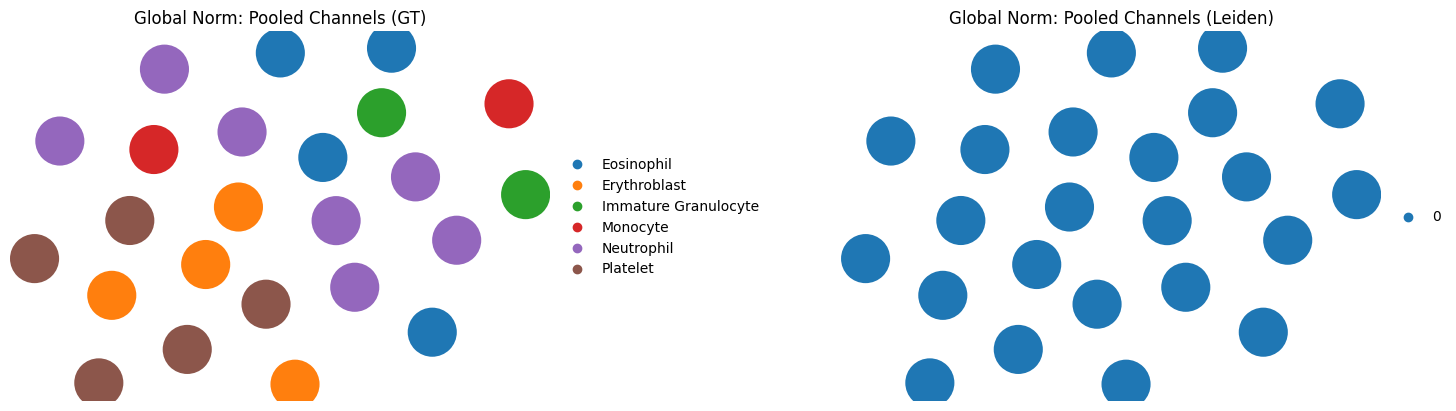

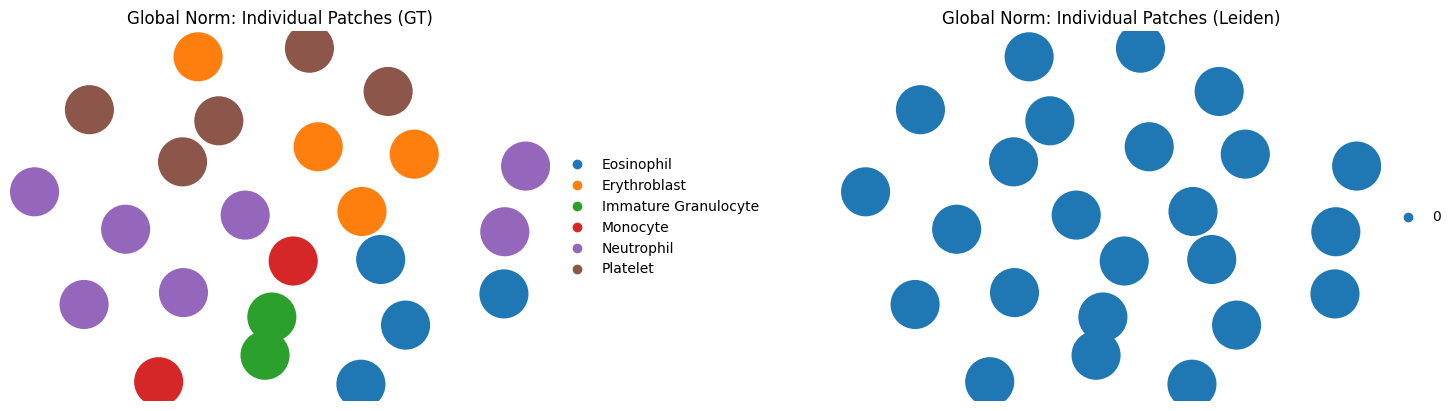

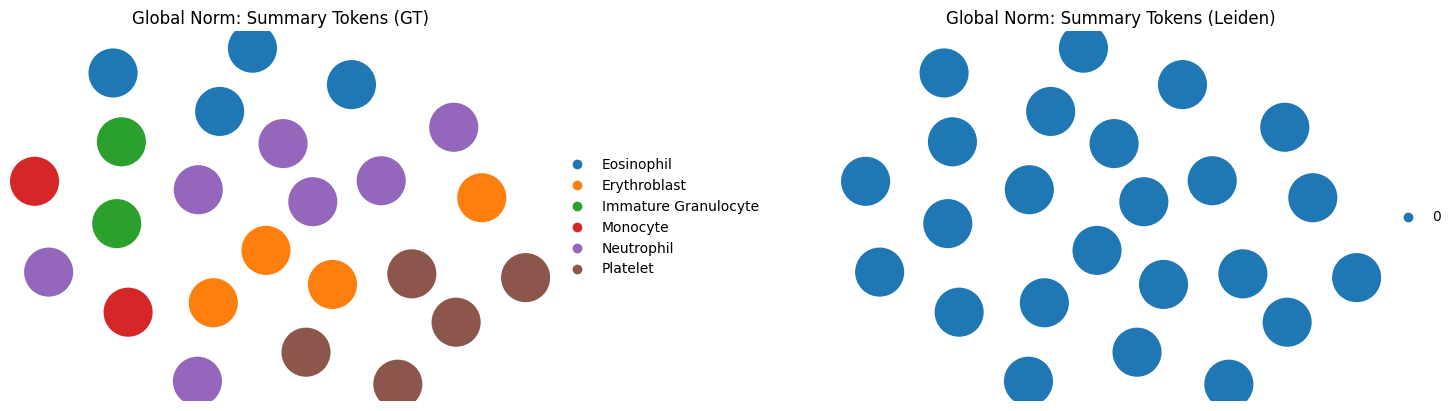

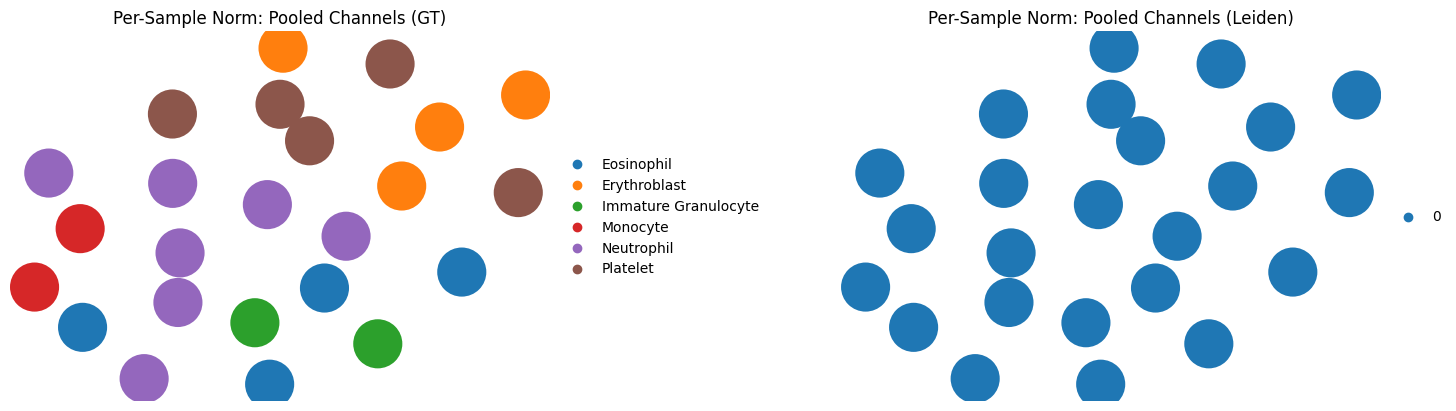

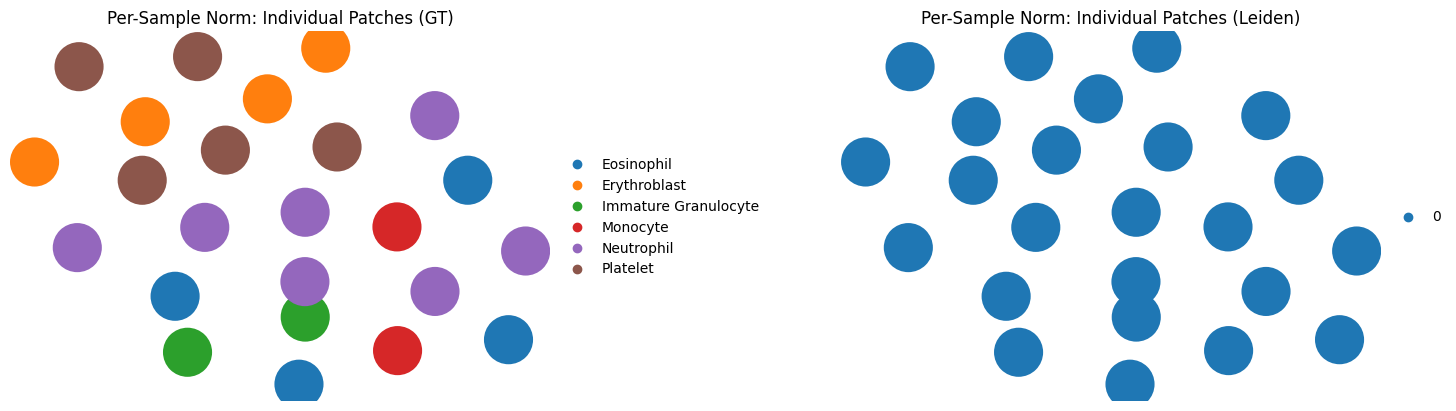

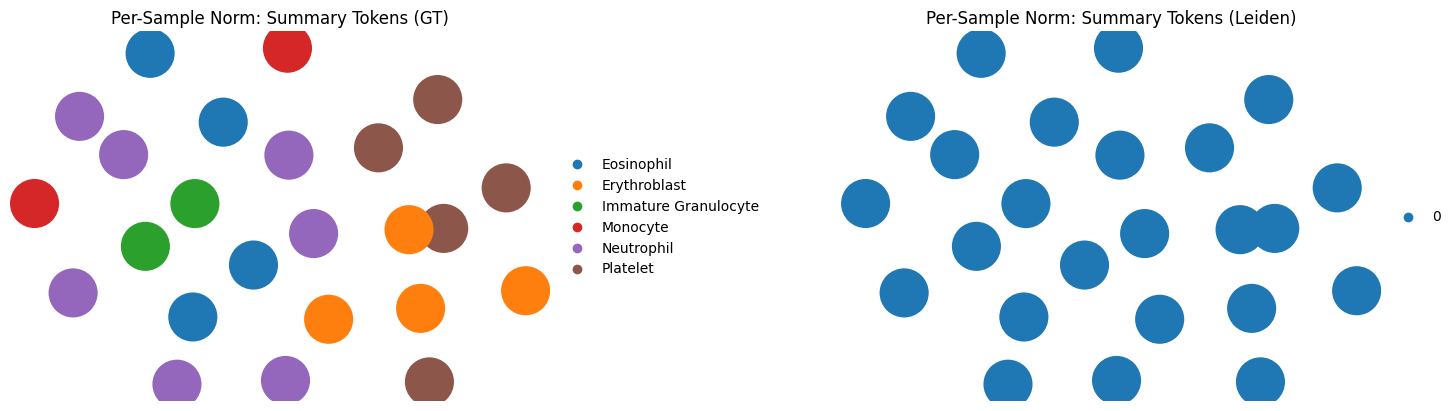

------------------------------
Result global_pooled: 24 samples, 1 clusters.
Result global_patches: 24 samples, 1 clusters.
Result global_summary: 24 samples, 1 clusters.
Result sample_pooled: 24 samples, 1 clusters.
Result sample_patches: 24 samples, 1 clusters.
Result sample_summary: 24 samples, 1 clusters.


In [15]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Konfiguration für die Klassennamen
class_names = [
    'Basophil', 'Eosinophil', 'Erythroblast', 'Immature Granulocyte',
    'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet'
]

# Vorbereitung der 6 Analyse-Szenarien
# Wir nutzen die Rückgabewerte: pooled, patches, summary und labels
analysis_configs = [
    # 1. Global Normalization
    {
        "id": "global_pooled",
        "emb": pooled_global, # (N, C, D) -> muss flatten werden
        "lbl": labels_global,
        "title": "Global Norm: Pooled Channels"
    },
    {
        "id": "global_patches",
        "emb": patches_global, # (N, C, H, W, D) -> muss flatten werden
        "lbl": labels_global,
        "title": "Global Norm: Individual Patches"
    },
    {
        "id": "global_summary",
        "emb": summary_global, # (N, H, W, D) -> muss flatten werden
        "lbl": labels_global,
        "title": "Global Norm: Summary Tokens"
    },
    # 2. Per-Sample Normalization
    {
        "id": "sample_pooled",
        "emb": pooled_sample,
        "lbl": labels_sample,
        "title": "Per-Sample Norm: Pooled Channels"
    },
    {
        "id": "sample_patches",
        "emb": patches_sample,
        "lbl": labels_sample,
        "title": "Per-Sample Norm: Individual Patches"
    },
    {
        "id": "sample_summary",
        "emb": summary_sample,
        "lbl": labels_sample,
        "title": "Per-Sample Norm: Summary Tokens"
    }
]

adatas = {}

for config in analysis_configs:
    print(f"--- Processing: {config['title']} ---")
    
    # Daten vorbereiten: Reshape auf (N, Features)
    # Egal ob (N, C, D) oder (N, C, H, W, D), wir flachen alles ab außer Dim 0
    raw_data = config['emb']
    n_samples = raw_data.shape[0]
    reshaped_features = raw_data.reshape(n_samples, -1)
    
    # 1. AnnData Objekt erstellen
    adata = sc.AnnData(X=reshaped_features)
    
    # 2. Labels hinzufügen
    adata.obs['cell_type'] = [class_names[int(l)] for l in config['lbl']]
    
   # 3. Scanpy Pipeline
    # Dynamische Anpassung: n_comps muss kleiner sein als n_samples
    n_pca_components = min(n_samples - 1, 50) 
    
    sc.tl.pca(adata, n_comps=n_pca_components) 
    sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=0.5, key_added='leiden_clusters')
    
    adatas[config['id']] = adata

# --- PLOTTING ---

# Wir plotten alle 6 Ergebnisse untereinander
for config in analysis_configs:
    key = config['id']
    current_title = config['title']
    
    sc.pl.umap(
        adatas[key], 
        color=['cell_type', 'leiden_clusters'], 
        wspace=0.4, 
        frameon=False, 
        title=[f"{current_title} (GT)", f"{current_title} (Leiden)"]
    )

# Output Summary
print("-" * 30)
for key, adata in adatas.items():
    print(f"Result {key}: {adata.n_obs} samples, {adata.obs['leiden_clusters'].nunique()} clusters.")